## Test overview

In [1]:
import pandas as pd
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
pd.set_option("display.max_columns", None)

import numpy as np
import os
import matplotlib.pyplot as plt

import plotly.express as px 
import plotly.graph_objects as go
from vessel_manoeuvring_models.data import mdl
import shutil


In [2]:
df_runs = pd.read_csv('../data/raw/runs.csv', index_col=0)

In [3]:
df_runs.head()

,project_number,series_number,run_number,test_number,model_number,ship_name,loading_condition_id,ascii_name,ship_speed,comment,file_path_ascii,file_path_ascii_temp,file_path_log,file_path_hdf5,date,test_type,facility,angle1,angle2,Körfallstyp,scale_factor,name,lcg,kg,gm,CW,TF,TA,BWL,KXX,KZZ,BTT1,CP,Volume,A0,RH,lpp,beam,ABULB,BKX,TWIN,DCLR,VDES,RHBL,ASKEG,PD,ARH,CFP,AIX,PDTDES,RTYPE,SFP,BKL,BKB,PROT,D,LSKEG,RR,XSKEG,NDES,AR,BR,BRA,IRUD,PTYPE,XRUD,AI,HSKEG,RSKEG,LOA,ship_type_id,xm,ym,zm,sailing
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
22605,40199079,1,1,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-18,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22606,40199079,1,2,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-21,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22607,40199079,1,3,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22608,40199079,1,4,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22609,40199079,1,5,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False


In [4]:
df_runs['series_number'].unique()

array([ 1,  5, 10])

In [5]:
df_runs['sailing'] = False
mask = df_runs['test_type']=='sailing'
df_runs.loc[mask,'sailing']=True
mask = df_runs['comment'].str.contains('GWA')
df_runs.loc[mask,'sailing']=True


In [6]:
df_runs.groupby(by=['test_type','comment']).first()['sailing']

test_type         comment              
reference speed   10.0 kn                  False
                  12.0 kn                  False
                  8.0 kn                   False
rodergrundvinkel  Rodergrundvinkel         False
sailing           Seglande 120deg           True
                  Seglande 55deg            True
                  Seglande GWA= -90deg      True
turning circle    Circle 35PS              False
                  Circle 35SB              False
zigzag            ZZ 10/10PS               False
                  ZZ 10/10PS - GWA= -90     True
                  ZZ 10/10SB               False
                  ZZ 10/10SB - GWA= -90     True
                  ZZ 20/20PS               False
                  ZZ 20/20PS - GWA= -90     True
                  ZZ 20/20SB               False
                  ZZ 20/20SB - GWA= -90     True
Name: sailing, dtype: bool

In [9]:
df_runs.to_csv('../data/raw/runs.csv')
df_runs.head()

,project_number,series_number,run_number,test_number,model_number,ship_name,loading_condition_id,ascii_name,ship_speed,comment,file_path_ascii,file_path_ascii_temp,file_path_log,file_path_hdf5,date,test_type,facility,angle1,angle2,Körfallstyp,scale_factor,name,lcg,kg,gm,CW,TF,TA,BWL,KXX,KZZ,BTT1,CP,Volume,A0,RH,lpp,beam,ABULB,BKX,TWIN,DCLR,VDES,RHBL,ASKEG,PD,ARH,CFP,AIX,PDTDES,RTYPE,SFP,BKL,BKB,PROT,D,LSKEG,RR,XSKEG,NDES,AR,BR,BRA,IRUD,PTYPE,XRUD,AI,HSKEG,RSKEG,LOA,ship_type_id,xm,ym,zm,sailing
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
22605,40199079,1,1,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-18,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22606,40199079,1,2,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-21,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22607,40199079,1,3,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22608,40199079,1,4,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False
22609,40199079,1,5,7,M5139-02-A,M5139-02-A,167,NaN,0.96177,12.0 kn,NaN,NaN,NaN,\\sspa.local\lab\MeasuredataMDL\40199079\001\0...,2020-09-22,reference speed,MDL,NaN,NaN,NaN,41.2,Design,-0.24432,0.438908,0.136092,NaN,0.206311,0.206311,NaN,0.331311,1.253641,NaN,NaN,0.441027,0.722775,NaN,5.014563,0.946602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,-0.214,False


In [8]:
df_runs['test_type'].unique()

<StringArray>
['reference speed', 'rodergrundvinkel', 'zigzag', 'turning circle', 'sailing']
Length: 5, dtype: str

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/22605.csv'

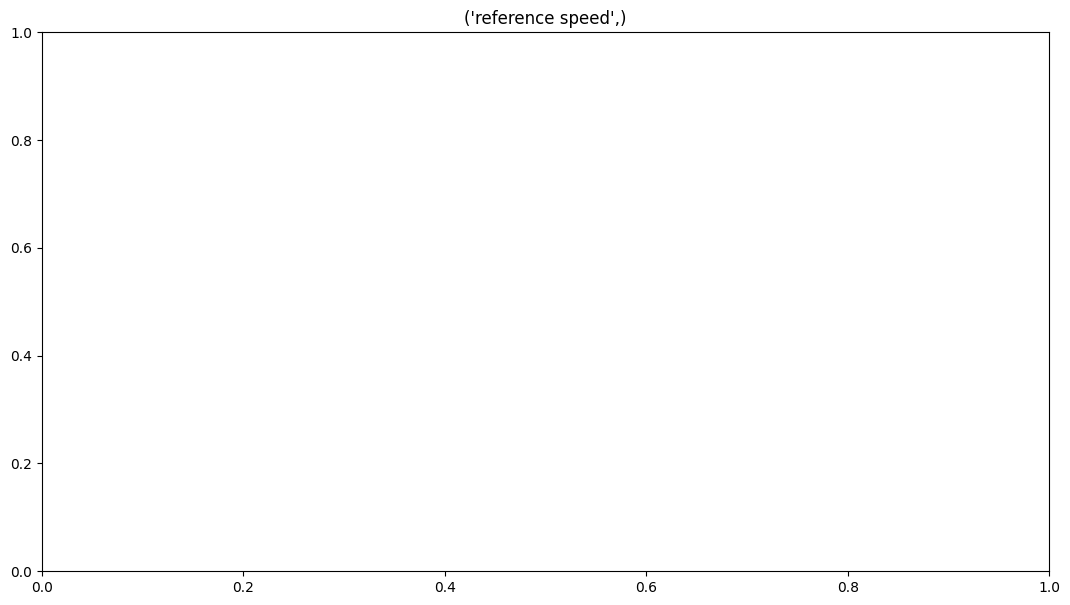

In [10]:
for test_type, group in df_runs.groupby(by=['test_type']):
    
    fig,ax=plt.subplots()
    ax.set_title(test_type)
    
    for id, row in group.iterrows():
        
        df = mdl.load_run(id=id)
        df = df.resample('3S').mean()        
        
        df.plot(x='y0', y='x0', ax=ax)
        
    ax.get_legend().set_visible(False)
    ax.axis('equal')
    ax.set_ylabel('x0')


In [ ]:
for (test_type,sailing), group in df_runs.groupby(by=['test_type','sailing']):
    
    data = pd.DataFrame()
    
    for id, row in group.iterrows():
        
        df = mdl.load_run(id=id)
        df = df.resample('2S').mean()        
        df['id'] = id    
        df['comment'] = row['comment']
                
        data = data.append(df)
    
    title = test_type
    if sailing:
        title+=' sailing'
    
    display(px.line(data, x='y0', y='x0', width=1000, height=1000, line_group='id', color='id', title=title, hover_data=['comment']))

In [ ]:
df = df_runs.groupby('sailing').get_group(False)

In [ ]:
for id, row in df.iterrows():
    
    shutil.copyfile(f'../data/raw/{id}.csv',os.path.join(r'E:\dev\wPCC_pipeline\data\01_raw',f'{id}.csv'))
    

In [ ]:
import yaml
global_dict = {}
global_dict['runs'] = list(df.index.astype(str))
with open(r'E:\dev\wPCC_pipeline\conf\base\runs_globals.yml', mode='w') as file:
    yaml.dump(global_dict, file)

In [ ]:
df.index.astype(str)